Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Loading model from: trained_model_branch160_80_40_20_20_40_80_160trunk160_80_40_20_20_40_80_160_iter200000.pt-200000.pt
Relativetrain L2 error: 0.13216213881969452


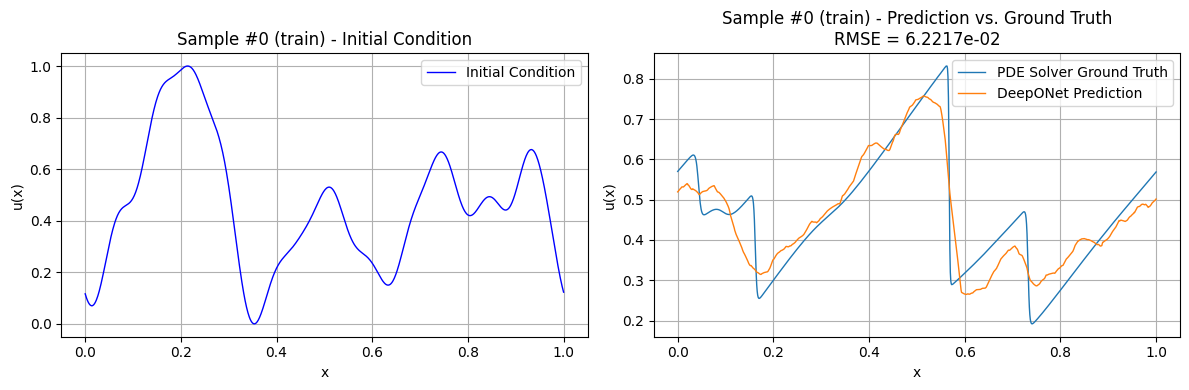

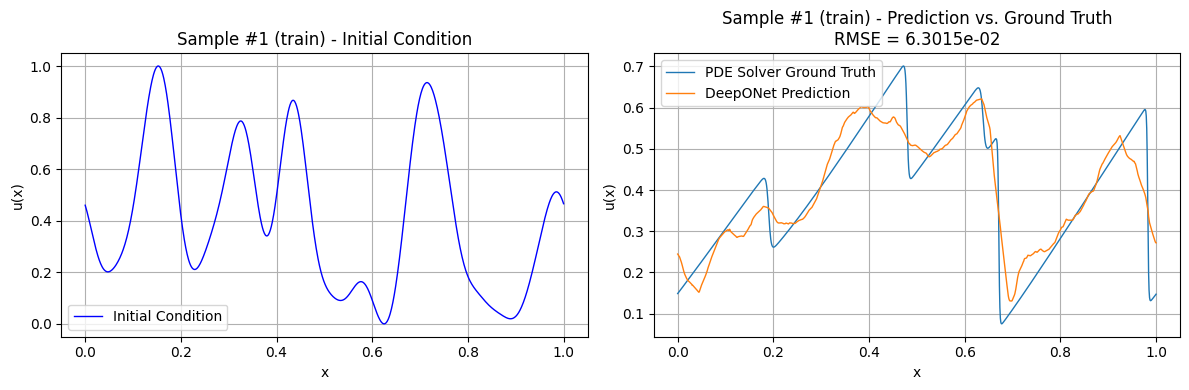

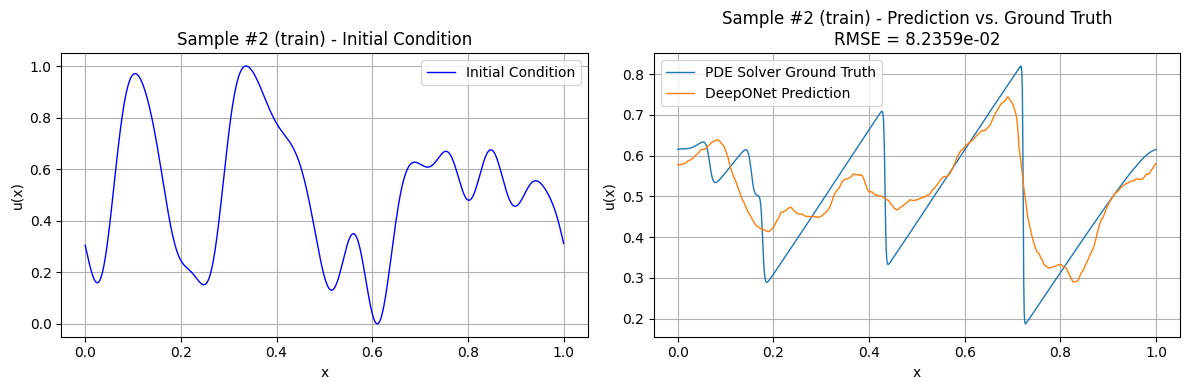

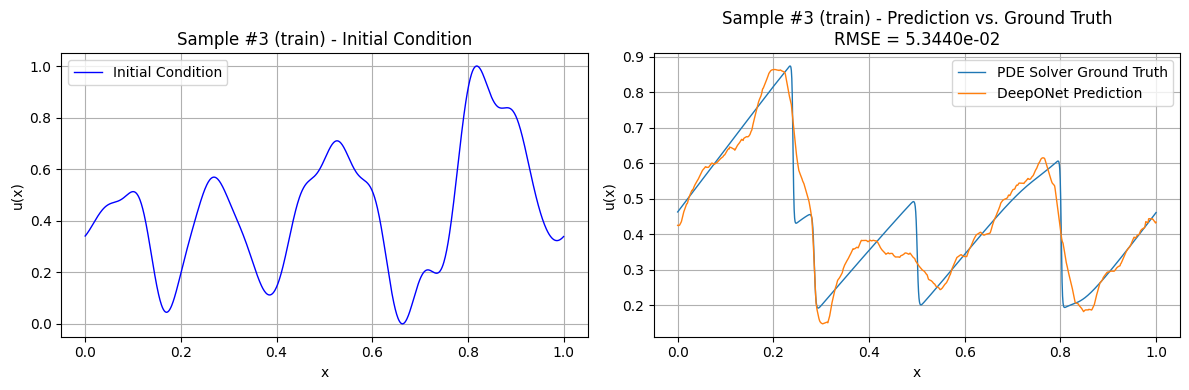

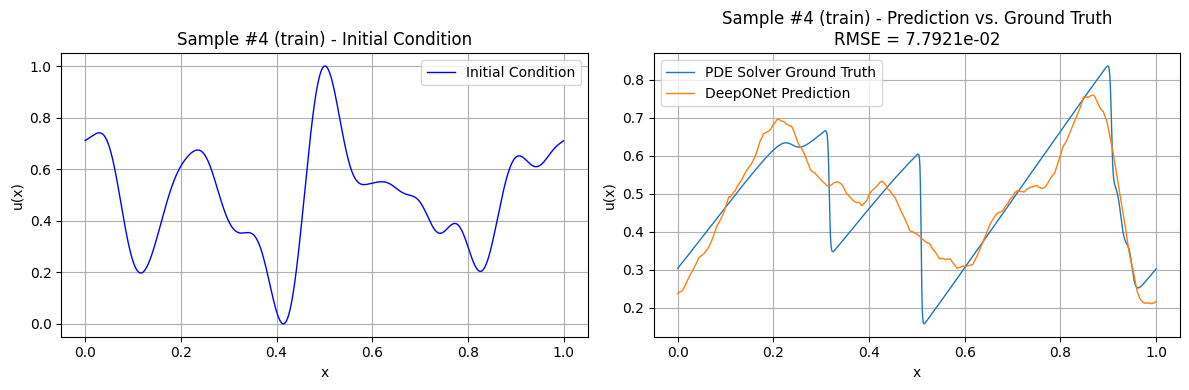

Loading model from: trained_model_branch160_80_40_20_20_40_80_160trunk160_80_40_20_20_40_80_160_iter200000.pt-200000.pt
Relativetest L2 error: 0.19365382194519043


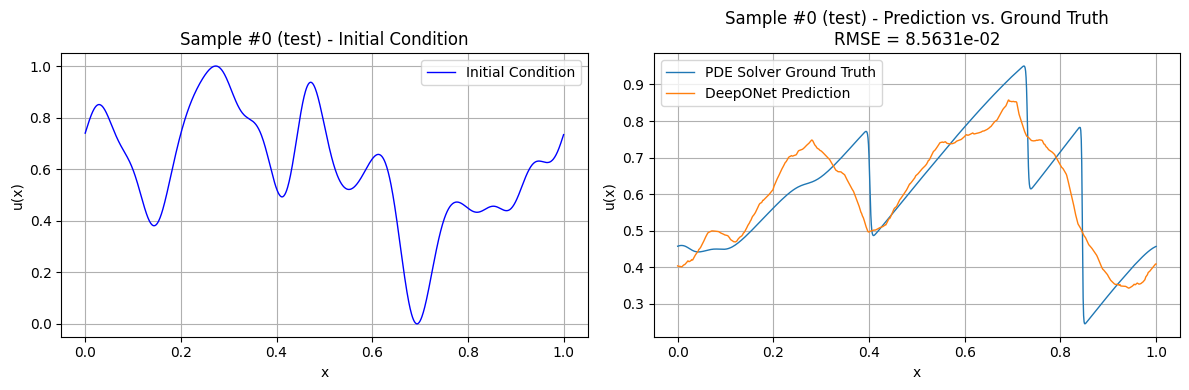

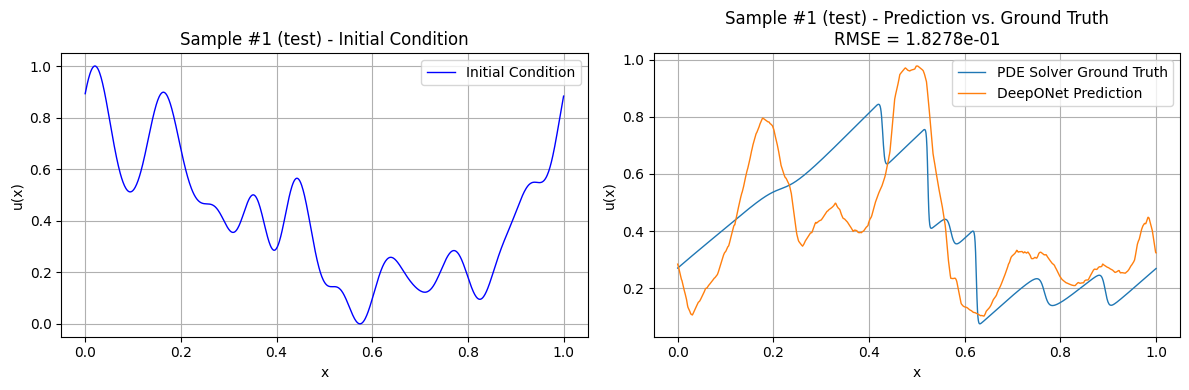

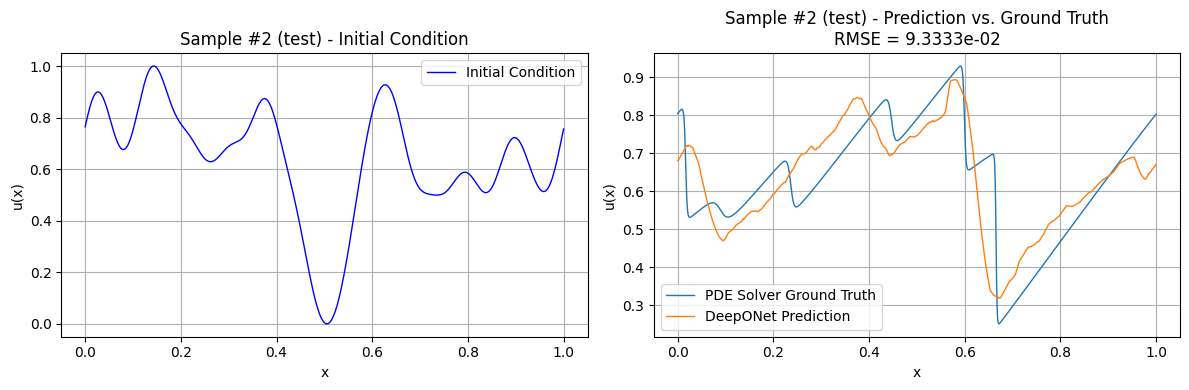

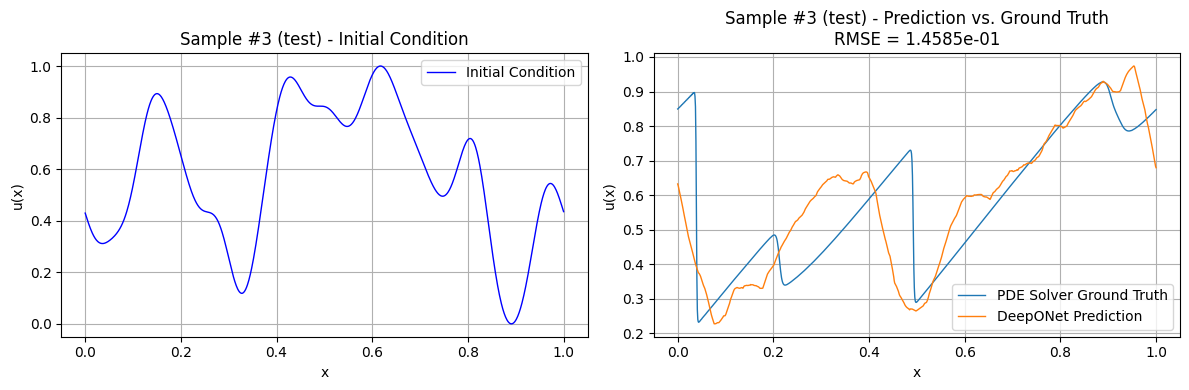

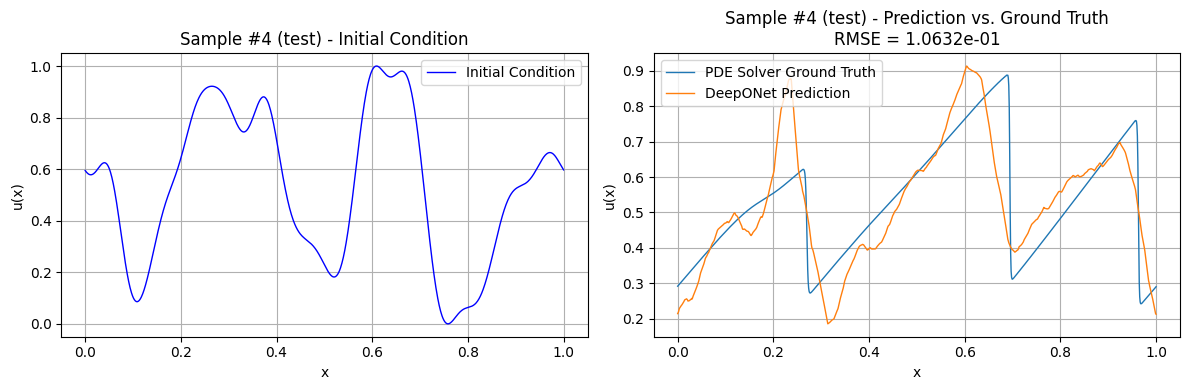

In [1]:
import deepxde as dde
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import sys
from pathlib import Path

# Load dataset
for mode in ["train", "test"]:
    if mode == "train":
        data_path = Path("../../datasets/dim1d_nx1024_N1400_train.pt")
    elif mode == "test":
        data_path = Path("../../datasets/dim1d_nx1024_N100_test.pt")
    else:
        pass
    d = torch.load(data_path, weights_only=False)

    X_test = (
        d["x"].to(torch.float32), 
        torch.linspace(0, 1, d["x"].shape[1]).unsqueeze(1).to(torch.float32)
    )
    y_test = d["y"].to(torch.float32)

    # Choose a network
    m = d["x"].shape[1]
    dim_x = 1
    branch_hidden_layer_dim = [160,80,40,20,20,40,80,160]
    trunk_hidden_layer_dim = [160,80,40,20,20,40,80,160]
    net = dde.nn.DeepONetCartesianProd(
        [m, *branch_hidden_layer_dim],  # Unpacks branch dimensions
        [dim_x, *trunk_hidden_layer_dim],  # Unpacks trunk dimensions
        "relu",
        "Glorot normal",
    )

    current_dir = Path(".")
    pt_files = list(current_dir.glob("*.pt"))
    pt_path = pt_files[0]
    print(f"Loading model from: {pt_path}")
    state_dict = torch.load(pt_path, map_location=torch.device('cpu'))["model_state_dict"]
    net.load_state_dict(state_dict)
    net.eval()

    with torch.no_grad():
        y_pred = net(X_test)
        error = torch.norm(y_pred - y_test) / torch.norm(y_test)
        print(f"Relative{mode} L2 error:", error.item())
        for idx in range(5):  # choose the sample index you want to plot
            x = torch.linspace(0, 1, y_test.shape[1])  # domain of the solution
            
            x_init = X_test[0][idx].cpu().numpy()
            y_true = y_test[idx].cpu().numpy()
            y_hat  = y_pred[idx].cpu().numpy()
            x      = x.cpu().numpy()
            
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))

            # Left plot: initial condition
            axs[0].plot(x, x_init, label='Initial Condition', color='blue', linewidth=1)
            axs[0].set_xlabel('x')
            axs[0].set_ylabel('u(x)')
            axs[0].set_title(f'Sample #{idx} ({mode}) - Initial Condition')
            axs[0].grid(True)
            axs[0].legend()

            # Compute RMSE
            rmse = np.sqrt(np.mean((y_true - y_hat) ** 2))

            # Right plot: ground truth and prediction
            axs[1].plot(x, y_true, label='PDE Solver Ground Truth', linewidth=1)
            axs[1].plot(x, y_hat, label='DeepONet Prediction', linewidth=1)
            axs[1].set_xlabel('x')
            axs[1].set_ylabel('u(x)')
            axs[1].set_title(f'Sample #{idx} ({mode}) - Prediction vs. Ground Truth\nRMSE = {rmse:.4e}')
            axs[1].grid(True)
            axs[1].legend()

            plt.tight_layout()
            plt.show()

In [6]:
X_test[idx].shape

torch.Size([1400, 1024])

In [6]:
X_test[0].shape

torch.Size([100, 1024])

In [7]:
X_test[1].shape

torch.Size([1024, 1])

In [4]:
y_pred.shape

torch.Size([100, 1024])

In [8]:
y_test.shape

torch.Size([100, 1024])